In [9]:
import torch
import qewton
import matplotlib.pyplot as plt

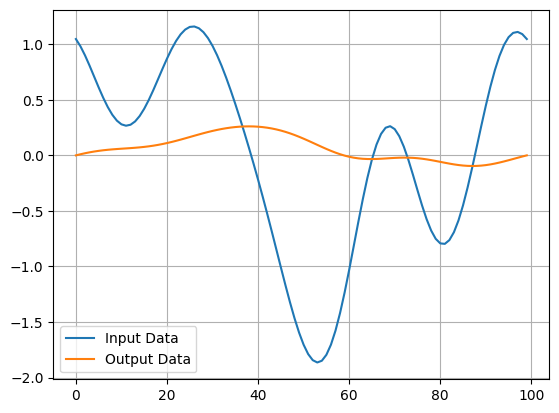

In [10]:
input_data = torch.load("../data/integrator/f_data.pt", weights_only=True)
output_data = torch.load("../data/integrator/u_data.pt", weights_only=True)

train_in_data, train_out_data = input_data[:4000], output_data[:4000]
test_in_data, test_out_data = input_data[4000:], output_data[4000:]

batch_size = 1000

plt.plot(input_data[0].numpy(), label="Input Data")
plt.plot(output_data[0].numpy(), label="Output Data")
plt.grid()
plt.legend()

In [11]:
F = qewton.config.Variable("f", 1)
U = qewton.config.Variable("u", 1)

input_config = qewton.config.DataConfiguration(
    qewton.config.BatchAxes(5000), 
    qewton.config.GeometryAxes(shape=(100, )), 
    qewton.config.FeatureAxes(F)
)
output_config = qewton.config.DataConfiguration(
    qewton.config.BatchAxes(5000), 
    qewton.config.GeometryAxes(shape=(100, )), 
    qewton.config.FeatureAxes(U)
)

dataset = qewton.data.ArrayLikeDataSet(
    data=[train_in_data, train_out_data], data_configs=[input_config, output_config]
)


In [12]:
data_loader = qewton.data.DataLoader(
    data_set=dataset,
    batch_size=batch_size,
    splitting_ratio=(1.0, 0.0, 0.0),
    shuffle_data=False,
)

In [13]:
model = qewton.algorithms.PCANet(
    input_variable=F,
    output_variable=U,
    pca_n_input=20,
    pca_n_output=20,
    data_source_node=data_loader,
    fcn_hidden_layers=2,
    fcn_hidden_neurons=50,
)

In [14]:
constraint = qewton.constraints.MSEConstraint()
computation_graph = qewton.Graph()
computation_graph.connect(data_loader.get_output_port(F), model.input_ports[0])
computation_graph.connect(data_loader.get_output_port(U), model.input_ports[1])
computation_graph.connect(model, constraint.input_1)
computation_graph.connect(data_loader.get_output_port(U), constraint.input_2)

In [15]:
adam_phase = qewton.optim.OptimizationPhase(
    optimizer=qewton.optim.Adam(),
    lr=0.001,
    max_iterations=2500,
)

trainer = qewton.optim.GraphBasedTrainer(
    optimization_phases=[adam_phase],
    graphs=[computation_graph],
    training_objectives=[constraint],
    device="cuda:0",
)

trainer.run()

Optimization Phase 1: 100%|██████████| 4000/4000 [01:48<00:00, 36.71it/s, loss=7.25e-5]  


Test MSE: 0.00020695985585916787


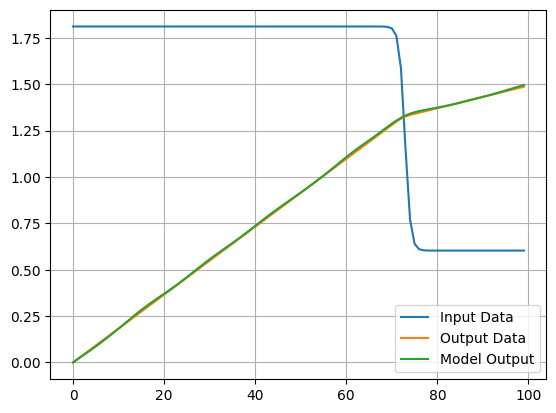

In [20]:
model.to("cpu")
model_out_test = model(test_in_data)
error = torch.mean((model_out_test - test_out_data) ** 2)
print(f"Test MSE: {error.item()}")

idx = 2
plt.plot(test_in_data[idx], label="Input Data")
plt.plot(test_out_data[idx], label="Output Data")
plt.plot(model_out_test[idx].detach().cpu().numpy(), label="Model Output")
plt.grid()
plt.legend()